In [27]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [28]:
city = '北京'

In [29]:
housing = pd.read_csv(f'processed_data/{city}/04_data.csv')

In [30]:
# fully print
print(housing.columns.tolist())

['城市', '区域', '板块', 'price', 'unit_price', '配备电梯', '挂牌时间', '上次交易', '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份', 'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry', 'log_price', 'log_unit_price', 'area', 'distance_to_center', 'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私

In [31]:
stats = housing.drop(columns=['城市', '区域', '板块', '挂牌时间', '上次交易', '核心卖点', '户型介绍', '周边配套', '交通出行'
                              ,'nearest_park_index','nearest_park_industry','x','y'])

In [32]:
from utils import Display

Display(stats)

Shape: (261159, 93)
Index(['price', 'unit_price', '配备电梯', '产权所属', '年份', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center',
       'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交

,Missing,Unique,Dtype
price,0,2818,float64
unit_price,0,99366,float64
配备电梯,0,2,int64
产权所属,0,2,int64
年份,1193,8,float64
...,...,...,...
category_is_Others,0,2,int64
category_is_High-Tech,0,2,int64
category_is_General-Mfg,0,2,int64
category_is_Heavy-Nuisance,0,2,int64


【col: price】
  - 450.0: 1974 次
  - 550.0: 1686 次
  - 420.0: 1667 次
  - 320.0: 1663 次
  - 330.0: 1647 次
----------------------------------------
【col: unit_price】
  - 100000.0: 112 次
  - 50000.0: 43 次
  - 125000.0: 41 次
  - 45455.0: 39 次
  - 62500.0: 37 次
----------------------------------------
【col: 配备电梯】
  - 1: 148836 次
  - 0: 112323 次
----------------------------------------
【col: 产权所属】
  - 2: 228758 次
  - 1: 32401 次
----------------------------------------
【col: 年份】
  - 2023.0: 133246 次
  - 2022.0: 102997 次
  - 2021.0: 12168 次
  - 2024.0: 9499 次
  - 2020.0: 1364 次
----------------------------------------
【col: nearest_park_dist_km】
  - 1.0558044660826411: 531 次
  - 0.1682971198726757: 527 次
  - 0.2633951853487862: 523 次
  - 12.279585246760934: 517 次
  - 1.251156431953514: 494 次
----------------------------------------
【col: log_price】
  - 6.1092475827643655: 1974 次
  - 6.309918278226516: 1686 次
  - 6.040254711277414: 1667 次
  - 5.768320995793772: 1663 次
  - 5.799092654460526: 1647 

In [33]:
missing_cols = stats.isnull().sum()
print(missing_cols[missing_cols > 0])

stats = stats.dropna(subset=['年份'])

年份    1193
dtype: int64


In [34]:
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

Y = stats['log_unit_price']
T = stats['nearest_park_dist_km']


base_cols = ['distance_to_center', 'area','nearest_subway_dist_km','administrative_level','block']
cat_cols = [col for col in stats.columns if col.startswith('category_is_')]
X_cols = base_cols + cat_cols
X = stats[X_cols]


exclude_cols = X_cols + ['log_unit_price', 'nearest_park_dist_km', 'price', 'unit_price', 'log_price']
W_cols = [col for col in stats.columns if col not in exclude_cols]
W = stats[W_cols]


In [35]:
print(W_cols)
print(X_cols)

['配备电梯', '产权所属', '年份', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房', '交易权属_is_一类经济适用房', '交易权属_is_二类经济适用房', '交易权属_is_央产房', '交易权属_is_限价商品房', '交易权属_is_定向安置房', '交易权属_is_自住型商品房', '房屋用途_is_普通住宅', '房屋用途_is_别墅', '房屋用途_is_车库', '房屋用途_is_商业办公类', '房屋用途_is_公寓', '房屋用途_is_住宅', '房屋用途_is_酒店式公寓', '房屋用途_is_平房', '房屋用途_is_商务型公寓', '房屋用途_is_公寓（住

In [36]:
T_log = 1/ T

In [37]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def objective(trial, X_full, y_full):
    # 建议在函数外部完成转换，避免重复消耗时间
    X_np = X_full.values.astype(np.float32) # GPU 喜欢 float32
    y_np = y_full.values.astype(np.float32) if isinstance(y_full, pd.Series) else y_full.astype(np.float32)

    params = {
        'n_estimators': 3000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        
        # --- 针对 GPU 的关键修改 ---
        'tree_method': 'hist',
        'device': 'cuda',       # 确保是 cuda
        'random_state': 42,
        'early_stopping_rounds': 50

    }
    
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_np)):
        X_train, X_valid = X_np[train_idx], X_np[valid_idx]
        y_train, y_valid = y_np[train_idx], y_np[valid_idx]
        
        # 如果数据量大，推荐在这里使用 xgb.DMatrix(X_train, label=y_train, device='cuda')
        model = XGBRegressor(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )
        
        fold_score = model.best_score
        cv_scores.append(fold_score)
        
        trial.report(fold_score, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)

# --- 准备特征 ---
# 确保 X 和 W 是 DataFrame，且已经拼接好
features = pd.concat([X, W], axis=1)

# 配置 Pruner
pruner = optuna.pruners.MedianPruner(n_warmup_steps=0) 

# --- 优化 Model_Y ---
print("🚀 正在优化 Model_Y (房价预测)...")
study_y = optuna.create_study(direction='minimize', pruner=pruner)
study_y.optimize(lambda trial: objective(trial, features, Y), n_trials=30)
best_params_y = study_y.best_params
best_params_y.update({'tree_method': 'hist', 'device': 'cuda'})

# --- 优化 Model_T ---
print("\n🚀 正在优化 Model_T (干预项预测)...")
study_t = optuna.create_study(direction='minimize', pruner=pruner)
# 假设 T_log 是你的干预项目标
study_t.optimize(lambda trial: objective(trial, features, T), n_trials=30)
best_params_t = study_t.best_params
best_params_t.update({'tree_method': 'hist', 'device': 'cuda'})

print("-" * 30)
print(f"Model_Y 最佳 RMSE: {study_y.best_value:.4f}")
print(f"Model_T 最佳 RMSE: {study_t.best_value:.4f}")

[I 2026-03-18 14:17:37,904] A new study created in memory with name: no-name-e9200fd5-b834-4ada-aeeb-6439ad3acf47


🚀 正在优化 Model_Y (房价预测)...


[I 2026-03-18 14:17:49,252] Trial 0 finished with value: 0.1527911292972615 and parameters: {'learning_rate': 0.0024513478804830987, 'max_depth': 6, 'subsample': 0.7874413924925496, 'colsample_bytree': 0.6907570499593707, 'reg_alpha': 0.02911906238442625, 'reg_lambda': 1.2220565794262859e-07, 'gamma': 0.8381003236571452}. Best is trial 0 with value: 0.1527911292972615.
[I 2026-03-18 14:18:12,493] Trial 1 finished with value: 0.1237995632133383 and parameters: {'learning_rate': 0.0045614816681990395, 'max_depth': 8, 'subsample': 0.9874609343618153, 'colsample_bytree': 0.8136000103852206, 'reg_alpha': 2.345768208592915e-08, 'reg_lambda': 1.0833583127411554e-06, 'gamma': 0.013583203671506398}. Best is trial 1 with value: 0.1237995632133383.
[I 2026-03-18 14:18:19,446] Trial 2 finished with value: 0.10682277092948782 and parameters: {'learning_rate': 0.2538463524038265, 'max_depth': 4, 'subsample': 0.6286161089406315, 'colsample_bytree': 0.7605447467979463, 'reg_alpha': 2.8649314441544053e


🚀 正在优化 Model_T (干预项预测)...


[I 2026-03-18 14:25:55,518] Trial 0 finished with value: 0.3201405552132621 and parameters: {'learning_rate': 0.003186940931219874, 'max_depth': 4, 'subsample': 0.512901459113324, 'colsample_bytree': 0.7547618080691065, 'reg_alpha': 4.51602559078097e-07, 'reg_lambda': 5.770152566443322e-07, 'gamma': 1.114285115961089e-07}. Best is trial 0 with value: 0.3201405552132621.
[I 2026-03-18 14:26:06,828] Trial 1 finished with value: 0.26462957038402507 and parameters: {'learning_rate': 0.0027816285955251092, 'max_depth': 6, 'subsample': 0.630942915330377, 'colsample_bytree': 0.7771686880287441, 'reg_alpha': 0.007323062910526021, 'reg_lambda': 7.514828075939025e-07, 'gamma': 2.935731745912603e-07}. Best is trial 1 with value: 0.26462957038402507.
[I 2026-03-18 14:26:12,490] Trial 2 finished with value: 0.26936652994718907 and parameters: {'learning_rate': 0.014978467479560133, 'max_depth': 3, 'subsample': 0.7172145015127762, 'colsample_bytree': 0.5721701975664428, 'reg_alpha': 2.31329667495181

------------------------------
Model_Y 最佳 RMSE: 0.0910
Model_T 最佳 RMSE: 0.0478


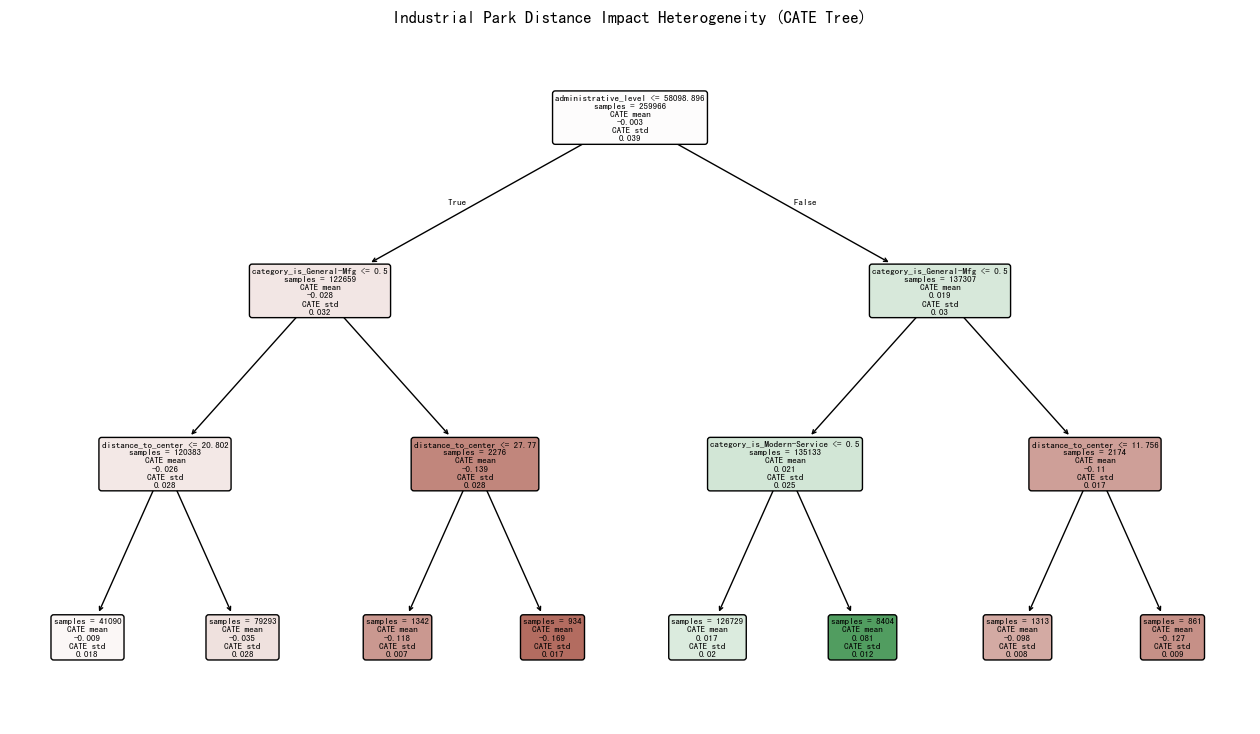

In [38]:
import warnings
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

warnings.filterwarnings('ignore')

est = LinearDML(
    model_y=XGBRegressor(**best_params_y),
    model_t=XGBRegressor(**best_params_t),
    discrete_treatment=False, # 距离是连续变量
    cv=5,                     # 5折交叉拟合
    random_state=42
)

est.fit(Y, T, X=X, W=W, inference="statsmodels")

intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=100)
intrp.interpret(est, X)

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  
plt.figure(figsize=(16, 9))
intrp.plot(feature_names=X_cols) # X_cols 是你传入 X 的特征名称列表
plt.title("Industrial Park Distance Impact Heterogeneity (CATE Tree)")
plt.show()

In [39]:
print(est.summary())

                               Coefficient Results                               
                           point_estimate stderr  zstat  pvalue ci_lower ci_upper
---------------------------------------------------------------------------------
distance_to_center                 -0.003    0.0 -10.863    0.0   -0.004   -0.003
area                                  0.0    0.0   0.217  0.828     -0.0    0.001
nearest_subway_dist_km              0.006  0.001   6.297    0.0    0.004    0.008
administrative_level                  0.0    0.0    5.44    0.0      0.0      0.0
block                                -0.0    0.0  -5.956    0.0     -0.0     -0.0
category_is_Others                  0.029  0.009   3.075  0.002     0.01    0.047
category_is_High-Tech               0.045  0.008   5.463    0.0    0.029    0.061
category_is_General-Mfg            -0.091  0.022   -4.25    0.0   -0.134   -0.049
category_is_Heavy-Nuisance         -0.062  0.014  -4.365    0.0    -0.09   -0.034
category_is_Mode

In [40]:
'''                           point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------------------
distance_to_center                 -0.004  0.001 -7.904    0.0   -0.006   -0.003
area                                  0.0    0.0  0.592  0.554     -0.0    0.001
nearest_subway_dist_km              0.008  0.001  8.192    0.0    0.006     0.01
administrative_level                  0.0    0.0  6.357    0.0      0.0      0.0
block                                -0.0    0.0 -5.798    0.0     -0.0     -0.0
category_is_Others                  0.033  0.015  2.264  0.024    0.004    0.062
category_is_High-Tech               0.059  0.013  4.353    0.0    0.032    0.085
category_is_General-Mfg            -0.143  0.041 -3.534    0.0   -0.223   -0.064
category_is_Heavy-Nuisance         -0.108  0.027 -4.072    0.0    -0.16   -0.056
category_is_Modern-Service          0.144  0.019  7.588    0.0    0.107    0.181
                       CATE Intercept Results                      
===================================================================
               point_estimate stderr zstat pvalue ci_lower ci_upper
-------------------------------------------------------------------
cate_intercept         -0.016  0.032 -0.49  0.624   -0.079    0.048'''

'                           point_estimate stderr zstat  pvalue ci_lower ci_upper\n--------------------------------------------------------------------------------\ndistance_to_center                 -0.004  0.001 -7.904    0.0   -0.006   -0.003\narea                                  0.0    0.0  0.592  0.554     -0.0    0.001\nnearest_subway_dist_km              0.008  0.001  8.192    0.0    0.006     0.01\nadministrative_level                  0.0    0.0  6.357    0.0      0.0      0.0\nblock                                -0.0    0.0 -5.798    0.0     -0.0     -0.0\ncategory_is_Others                  0.033  0.015  2.264  0.024    0.004    0.062\ncategory_is_High-Tech               0.059  0.013  4.353    0.0    0.032    0.085\ncategory_is_General-Mfg            -0.143  0.041 -3.534    0.0   -0.223   -0.064\ncategory_is_Heavy-Nuisance         -0.108  0.027 -4.072    0.0    -0.16   -0.056\ncategory_is_Modern-Service          0.144  0.019  7.588    0.0    0.107    0.181\n               

In [41]:
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 定义并训练因果森林
# model_y 和 model_t 建议使用足够强大的非线性模型，如随机森林或 GBDT
cest = CausalForestDML(
    model_y=XGBRegressor(**best_params_y),
    model_t=XGBRegressor(**best_params_t),
    criterion='het',  # 专门用于捕捉异质性
    n_estimators=500,
    min_samples_leaf=10,
    random_state=42
)


cest.fit(Y, T_log, X=X, W=W)

# 2. 计算每个样本的处理效应 (Marginal Effect: 距离每增加1km，房价变动多少)
treatment_effects = cest.effect(X)

# 3. 将结果放入 DataFrame 方便绘图
results_df = X.copy()
results_df['point_effect'] = treatment_effects

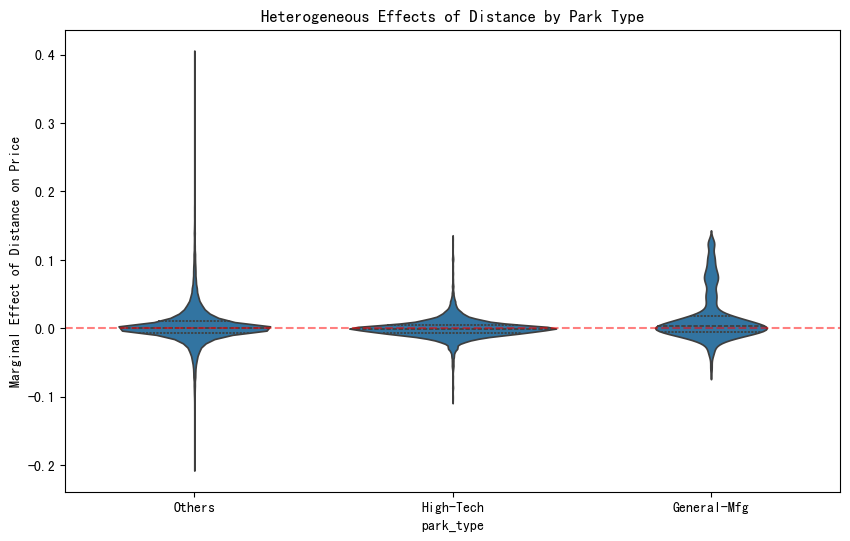

In [42]:
# 假设你的 category 已经转成了 dummy，我们需要转回类别标签方便画图
def get_category(row):
    if row['category_is_High-Tech'] == 1: return 'High-Tech'
    if row['category_is_General-Mfg'] == 1: return 'General-Mfg'
    return 'Others'

results_df['park_type'] = results_df.apply(get_category, axis=1)

plt.figure(figsize=(10, 6))
sns.violinplot(x='park_type', y='point_effect', data=results_df, inner="quart")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Heterogeneous Effects of Distance by Park Type")
plt.ylabel("Marginal Effect of Distance on Price")
plt.show()

检测到曲线第 1 次穿过 0 刻度线，距离为: 13.54 km
检测到曲线第 2 次穿过 0 刻度线，距离为: 48.13 km


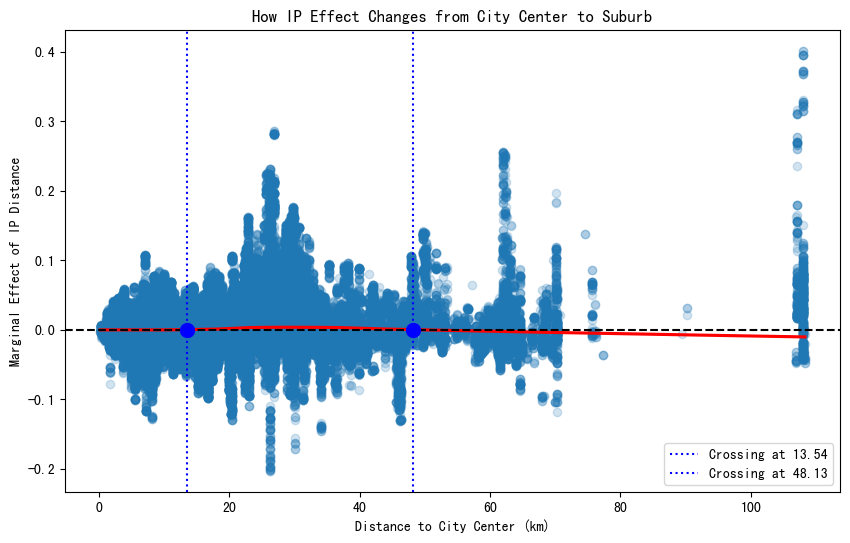

In [44]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.interpolate import interp1d

# 1. 手动计算 LOWESS 平滑曲线
# lowess 返回的是一个形状为 (n, 2) 的数组，第一列是 x，第二列是平滑后的 y
# 注意：lowess 默认会对 x 进行排序
lowess_results = sm.nonparametric.lowess(
    results_df['point_effect'], 
    results_df['distance_to_center'], 
    frac=0.666  # 这是 sns.regplot 默认的平滑窗口比例
)

# 提取平滑后的 x 和 y
x_smooth = lowess_results[:, 0]
y_smooth = lowess_results[:, 1]

# 2. 寻找穿过 0 的点
# 检查相邻的两个点是否异号
zero_crossings = []
for i in range(len(y_smooth) - 1):
    if (y_smooth[i] > 0 and y_smooth[i+1] < 0) or (y_smooth[i] < 0 and y_smooth[i+1] > 0):
        # 线性插值公式计算精确的 x 截距：
        # x = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1, x2 = x_smooth[i], x_smooth[i+1]
        y1, y2 = y_smooth[i], y_smooth[i+1]
        x_zero = x1 - y1 * (x2 - x1) / (y2 - y1)
        zero_crossings.append(x_zero)

# 3. 输出结果并绘图验证
if zero_crossings:
    for idx, val in enumerate(zero_crossings):
        print(f"检测到曲线第 {idx+1} 次穿过 0 刻度线，距离为: {val:.2f} km")
else:
    print("曲线未穿过 0 刻度线")

# 4. (可选) 在原图上标记出来
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='distance_to_center', y='point_effect', data=results_df, 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, lowess=True)
plt.axhline(0, color='black', linestyle='--')

# 绘制找到的交点
for x_val in zero_crossings:
    plt.axvline(x_val, color='blue', linestyle=':', label=f'Crossing at {x_val:.2f}')
    plt.scatter([x_val], [0], color='blue', s=100, zorder=5)

plt.title("How IP Effect Changes from City Center to Suburb")
plt.xlabel("Distance to City Center (km)")
plt.ylabel("Marginal Effect of IP Distance")
plt.legend()
plt.show()

In [47]:
ate = cest.ate(X)
ate_interval = cest.ate_interval(X)
print(f"平均处理效应: {ate:.4f}, 区间: {ate_interval}")

平均处理效应: 0.0034, 区间: (-0.02817485117037712, 0.03489772386136293)


In [49]:
# 得到各个变量对异质性贡献的权重
importances = cest.feature_importances_